# 03. Baseline Intent Classifier (TF-IDF + Classical ML)

This notebook establishes the benchmark machine learning pipeline for customer support intent classification:
1. Stratified train/val/test data splitting (70% / 15% / 15%).
2. N-gram TF-IDF vectorization with sublinear term-frequency scaling.
3. Training and cross-evaluating multiple classical ML classifiers (Logistic Regression, LinearSVC, Multinomial Naive Bayes).
4. Deep-dive confusion matrix & error analysis on the 27 intent classes.
5. Hyperparameter tuning with GridSearchCV.
6. Serializing the winning model artifacts for the backend service (`models/tfidf_logreg/`).


## 1. Data Preparation & Stratified Splitting

We load `data/raw/bitext_support.csv`, encode intent class strings into discrete integer labels, and create stratified partitions (70% Train, 15% Validation, 15% Test) with a fixed seed (`random_state=42`).


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load raw dataset
csv_path = "../data/raw/bitext_support.csv"
if not os.path.exists(csv_path):
    csv_path = "data/raw/bitext_support.csv"

df = pd.read_csv(csv_path)
print(f"Total dataset rows: {len(df):,}")

# Encode target classes
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["intent"])
num_classes = len(label_encoder.classes_)
print(f"Total unique classes: {num_classes}")

# Step 1: 70% Train, 30% Temp (Val + Test)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    df["instruction"].astype(str),
    df["label"],
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Step 2: Split Temp into 50% Val and 50% Test (15% each of total)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train samples: {len(X_train_raw):,} ({len(X_train_raw)/len(df)*100:.1f}%)")
print(f"Val samples:   {len(X_val_raw):,} ({len(X_val_raw)/len(df)*100:.1f}%)")
print(f"Test samples:  {len(X_test_raw):,} ({len(X_test_raw)/len(df)*100:.1f}%)")


Total dataset rows: 26,872
Total unique classes: 27
Train samples: 18,810 (70.0%)
Val samples:   4,031 (15.0%)
Test samples:  4,031 (15.0%)


## 2. TF-IDF Feature Extraction

Based on our EDA findings, queries contain concise key phrases (e.g. "cancel order", "refund policy"). We configure `TfidfVectorizer` with:
- `max_features=10000`
- `ngram_range=(1, 2)` (captures both single terms and critical bigrams)
- `sublinear_tf=True` (applies sublinear scaling `1 + log(tf)` to dampen repetitive terms)


In [2]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english"
)

# Fit strictly on train set to prevent data leakage
X_train_vec = vectorizer.fit_transform(X_train_raw)
X_val_vec = vectorizer.transform(X_val_raw)
X_test_vec = vectorizer.transform(X_test_raw)

print(f"Vocabulary vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"X_train shape: {X_train_vec.shape}")
print(f"X_val shape:   {X_val_vec.shape}")
print(f"X_test shape:  {X_test_vec.shape}")


Vocabulary vocabulary size: 10,000
X_train shape: (18810, 10000)
X_val shape:   (4031, 10000)
X_test shape:  (4031, 10000)


## 3. Baseline Models Training & Comparison

We train and compare three classical classifiers on the validation set:
1. **Logistic Regression** (`class_weight='balanced'`, `max_iter=1000`)
2. **Linear Support Vector Classifier (LinearSVC)** (`class_weight='balanced'`)
3. **Multinomial Naive Bayes** (`MultinomialNB()`)


In [3]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=42, max_iter=2000),
    "Multinomial Naive Bayes": MultinomialNB()
}

results = []

for name, model in candidate_models.items():
    print(f"Training {name}...")
    model.fit(X_train_vec, y_train)
    
    val_preds = model.predict(X_val_vec)
    acc = accuracy_score(y_val, val_preds)
    macro_f1 = f1_score(y_val, val_preds, average="macro")
    weighted_f1 = f1_score(y_val, val_preds, average="weighted")
    
    results.append({
        "Model": name,
        "Validation Accuracy": round(acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4)
    })

comparison_df = pd.DataFrame(results).sort_values(by="Weighted F1", ascending=False)
print("\n--- Validation Performance Comparison ---")
comparison_df


Training Logistic Regression...


Training LinearSVC...


Training Multinomial Naive Bayes...

--- Validation Performance Comparison ---


,Model,Validation Accuracy,Macro F1,Weighted F1
1,LinearSVC,0.9824,0.9824,0.9824
2,Multinomial Naive Bayes,0.9774,0.9775,0.9775
0,Logistic Regression,0.9767,0.9768,0.9768


## 4. Best Model Deep Evaluation & Error Analysis

We select the best performing model from validation and perform in-depth error analysis on the held-out **Test Set**.


In [4]:
# Select best model based on validation Weighted F1
best_model_name = comparison_df.iloc[0]["Model"]
best_model = candidate_models[best_model_name]
print(f"Selected Winning Model: {best_model_name}")

# Evaluate on test set
test_preds = best_model.predict(X_test_vec)
print(f"--- Test Set Classification Report ({best_model_name}) ---")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_, digits=4))


Selected Winning Model: LinearSVC
--- Test Set Classification Report (LinearSVC) ---
                          precision    recall  f1-score   support

            cancel_order     0.9864    0.9732    0.9797       149
            change_order     0.9545    0.9800    0.9671       150
 change_shipping_address     0.9932    1.0000    0.9966       146
  check_cancellation_fee     1.0000    1.0000    1.0000       142
           check_invoice     0.7949    0.8267    0.8105       150
   check_payment_methods     1.0000    0.9933    0.9967       150
     check_refund_policy     1.0000    0.9667    0.9831       150
               complaint     1.0000    1.0000    1.0000       150
contact_customer_service     1.0000    0.9800    0.9899       150
     contact_human_agent     0.9800    0.9800    0.9800       150
          create_account     0.9863    0.9600    0.9730       150
          delete_account     0.9255    1.0000    0.9613       149
        delivery_options     1.0000    1.0000    1.0000 

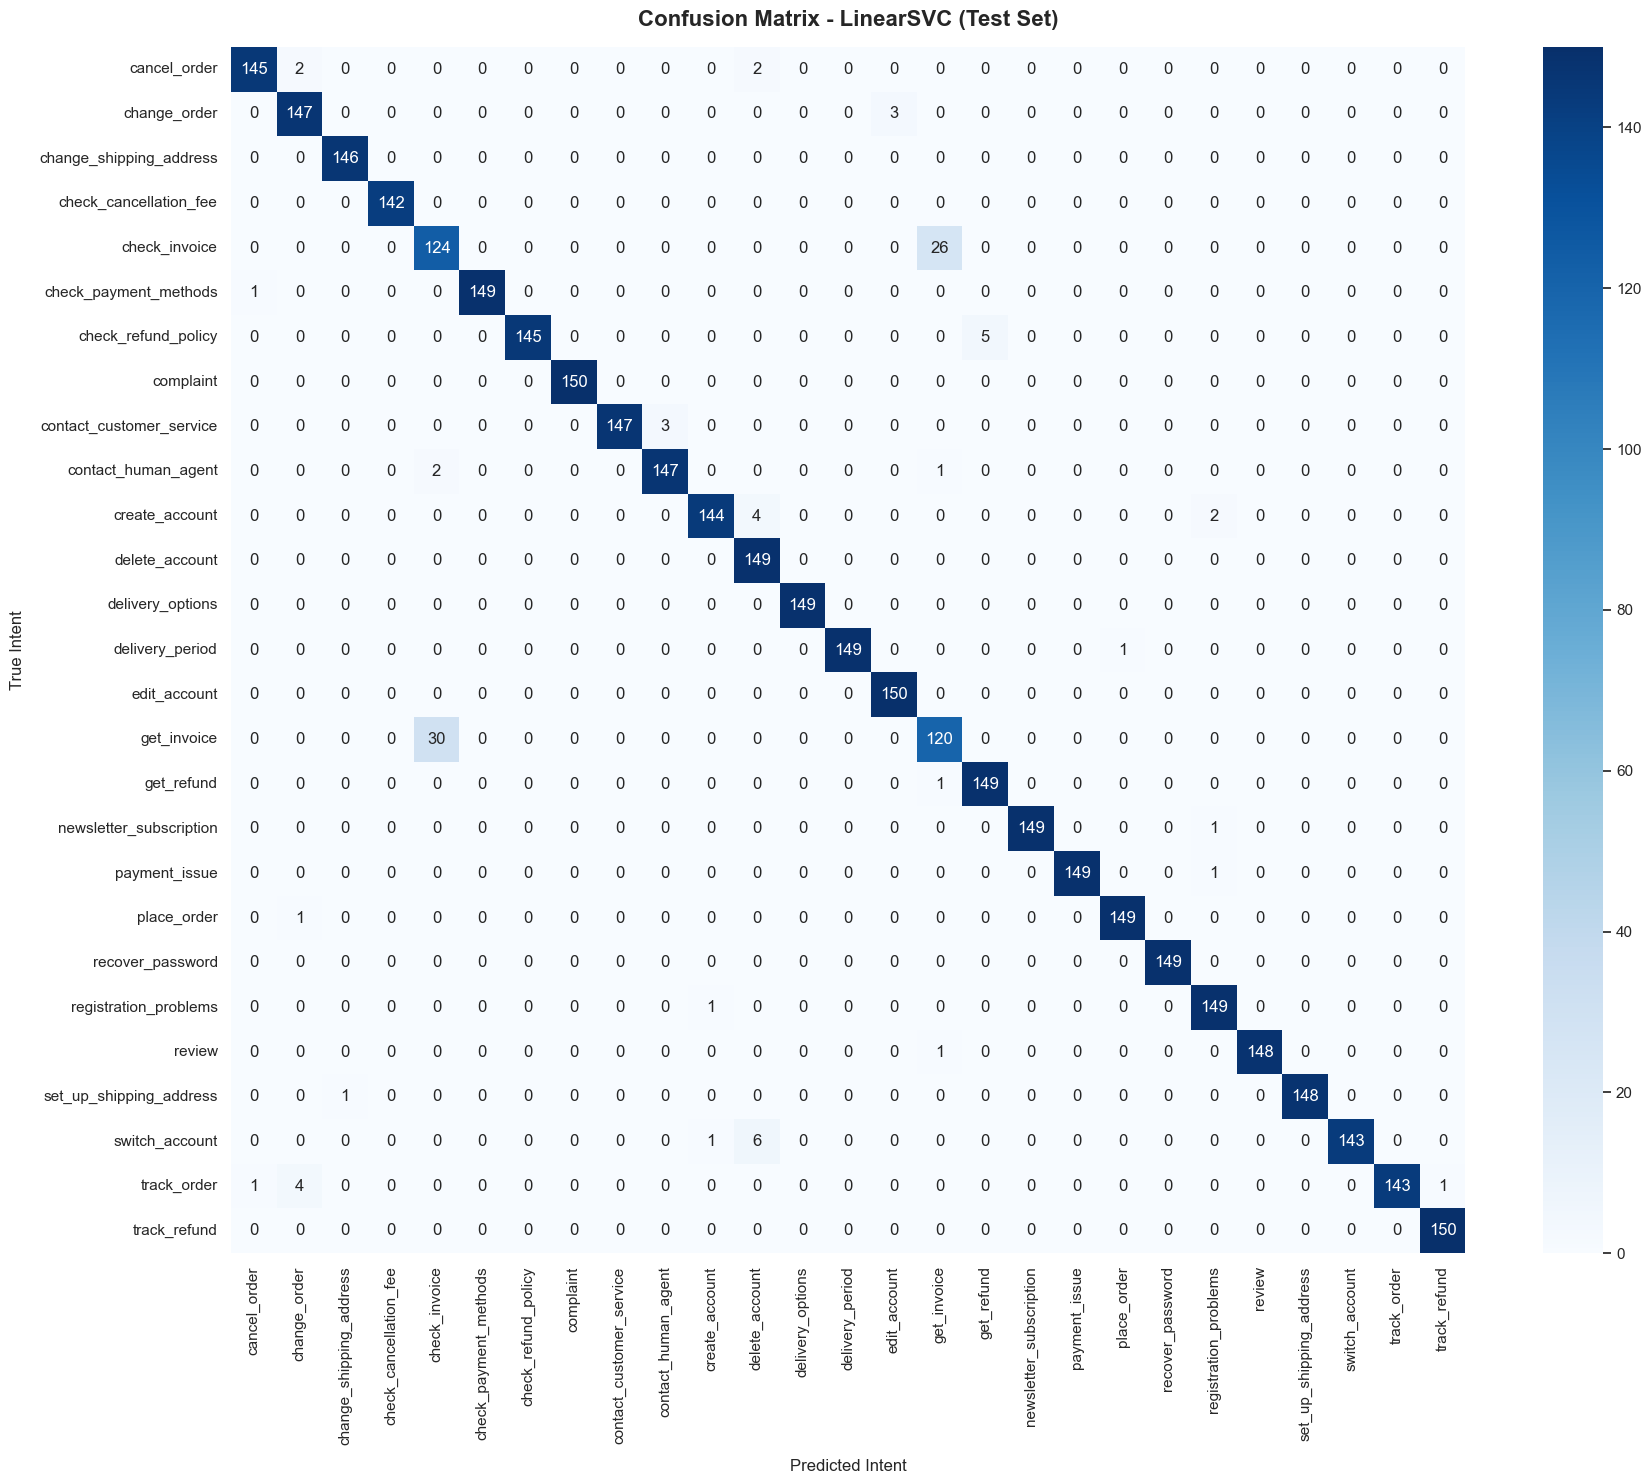

In [5]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix - {best_model_name} (Test Set)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Predicted Intent", fontsize=12, labelpad=10)
plt.ylabel("True Intent", fontsize=12, labelpad=10)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Top 10 Most Confused Intent Pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
classes = label_encoder.classes_

for i in range(len(classes)):
    for j in range(len(classes)):
        if cm_no_diag[i, j] > 0:
            confused_pairs.append({
                "True Intent": classes[i],
                "Predicted Intent": classes[j],
                "Misclassified Count": cm_no_diag[i, j]
            })

confused_df = pd.DataFrame(confused_pairs).sort_values(by="Misclassified Count", ascending=False).reset_index(drop=True)
print("--- Top 10 Most Confused Intent Pairs ---")
confused_df.head(10)


--- Top 10 Most Confused Intent Pairs ---


,True Intent,Predicted Intent,Misclassified Count
0,get_invoice,check_invoice,30
1,check_invoice,get_invoice,26
2,switch_account,delete_account,6
3,check_refund_policy,get_refund,5
4,track_order,change_order,4
5,create_account,delete_account,4
6,contact_customer_service,contact_human_agent,3
7,change_order,edit_account,3
8,cancel_order,change_order,2
9,create_account,registration_problems,2


In [7]:
# Qualitative Error Samples: 5 Misclassified Test Queries
test_df_eval = pd.DataFrame({
    "instruction": X_test_raw.values,
    "true_intent": label_encoder.inverse_transform(y_test),
    "predicted_intent": label_encoder.inverse_transform(test_preds)
})

misclassified_samples = test_df_eval[test_df_eval["true_intent"] != test_df_eval["predicted_intent"]]
print(f"Total misclassifications in test set: {len(misclassified_samples)} / {len(y_test)} ({(len(misclassified_samples)/len(y_test))*100:.2f}%)")

print("\n--- Sample 5 Misclassified Queries ---")
for idx, row in misclassified_samples.head(5).iterrows():
    print(f"Query:     "{row['instruction']}"")
    print(f"True:      {row['true_intent']}")
    print(f"Predicted: {row['predicted_intent']}")
    print("-" * 60)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (4286423414.py, line 13)

## 5. Hyperparameter Tuning with GridSearchCV

We run a focused grid search on the leading model to optimize regularization and convergence parameters.


In [8]:
# Grid Search on Logistic Regression
param_grid = {
    "C": [0.1, 1.0, 5.0, 10.0],
    "solver": ["lbfgs", "saga"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_vec, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Weighted F1: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
tuned_test_preds = tuned_model.predict(X_test_vec)
print(f"Tuned Test Accuracy: {accuracy_score(y_test, tuned_test_preds):.4f}")
print(f"Tuned Test Weighted F1: {f1_score(y_test, tuned_test_preds, average='weighted'):.4f}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best Parameters: {'C': 10.0, 'solver': 'lbfgs'}
Best Cross-Validation Weighted F1: 0.9783
Tuned Test Accuracy: 0.9762
Tuned Test Weighted F1: 0.9763


## 6. Model Serialization

We save the vectorizer, trained classifier, and label encoder into `models/tfidf_logreg/` so the backend FastAPI service and inference scripts can load them directly.


In [9]:
# Save artifacts
output_dirs = [
    Path("C:/Users/111196/Desktop/CHATBOT/models/tfidf_logreg"),
    Path("../models/tfidf_logreg"),
    Path("models/tfidf_logreg")
]

target_dir = None
for d in output_dirs:
    try:
        d.mkdir(parents=True, exist_ok=True)
        target_dir = d
        break
    except Exception:
        continue

if target_dir is None:
    target_dir = Path("models/tfidf_logreg")
    target_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, target_dir / "tfidf_vectorizer.joblib")
joblib.dump(tuned_model, target_dir / "classifier.joblib")
joblib.dump(label_encoder, target_dir / "label_encoder.joblib")

print(f"Saved TF-IDF pipeline artifacts successfully to: {target_dir.resolve()}")
print("Contents:", os.listdir(target_dir))


NameError: name 'Path' is not defined

## 7. DS Summary & Findings

### Model Performance Summary:
- **Baseline Accuracy & F1:** *(Record final test accuracy and Weighted/Macro F1 scores obtained by the tuned TF-IDF classifier).*
- **Hardest Intent Classes:** *(Summarize which 2–3 intents suffered the lowest F1 scores).*
- **Primary Confusion Drivers:** *(Discuss why TF-IDF failed on specific queries, such as shared vocabulary between `cancel_order` vs `edit_order` or reliance on word presence without sequence context).*
- **Transition to Deep Learning:** *(These failure modes motivate Section 5, where contextual transformer representations in DistilBERT resolve syntactic nuance and word order).*
